In [2]:
%%html
<style>
table {display: inline-block}
td {text-align:left}
.consoleMachineFont {color:blue;font-family:Courier}
.consoleUserFont {font-family:Courier}
</style>

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def generate_velocities(N, temperature, mass, rng):
    sigma = np.sqrt(temperature / mass)
    return rng.normal(0, sigma, size=(N, 2))


def move_particles(positions, velocities, dt):
    return positions + velocities * dt


def find_wall_collisions(positions, box_length):
    return {
        'left': positions[:, 0] < 0,
        'right': positions[:, 0] > box_length,
        'bottom': positions[:, 1] < 0,
        'top': positions[:, 1] > box_length,
    }


def wall_momentum_transfer(velocities, collisions, mass):
    hit_vertical_wall = collisions['left'] | collisions['right']
    hit_horizontal_wall = collisions['bottom'] | collisions['top']

    vertical_momentum = 2 * mass * np.sum(
        np.abs(velocities[hit_vertical_wall, 0])
    )
    horizontal_momentum = 2 * mass * np.sum(
        np.abs(velocities[hit_horizontal_wall, 1])
    )
    return vertical_momentum + horizontal_momentum


def reflect_from_walls(positions, velocities, box_length, collisions):
    left = collisions['left']
    right = collisions['right']
    bottom = collisions['bottom']
    top = collisions['top']

    hit_x_wall = left | right
    hit_y_wall = bottom | top

    new_positions = positions.copy()
    new_velocities = velocities.copy()

    new_positions[left, 0] = -positions[left, 0]
    new_positions[right, 0] = 2 * box_length - positions[right, 0]
    new_velocities[hit_x_wall, 0] = -velocities[hit_x_wall, 0]

    new_positions[bottom, 1] = -positions[bottom, 1]
    new_positions[top, 1] = 2 * box_length - positions[top, 1]
    new_velocities[hit_y_wall, 1] = -velocities[hit_y_wall, 1]

    return new_positions, new_velocities


def simulation_step(positions, velocities, box_length, dt, mass):
    moved_positions = move_particles(positions, velocities, dt)
    collisions = find_wall_collisions(moved_positions, box_length)
    momentum = wall_momentum_transfer(velocities, collisions, mass)
    new_positions, new_velocities = reflect_from_walls(
        moved_positions, velocities, box_length, collisions
    )
    return new_positions, new_velocities, momentum


def initial_state(N, box_length, temperature, mass, seed):
    rng = np.random.default_rng(seed)
    positions = rng.uniform(0, box_length, size=(N, 2))
    velocities = generate_velocities(N, temperature, mass, rng)
    return positions, velocities


class ParticleSystem:
    def __init__(self, N, box_length, temperature, mass, dt, seed):
        self.N = N
        self.box_length = box_length
        self.temperature = temperature
        self.mass = mass
        self.dt = dt
        self.positions, self.velocities = initial_state(
            N, box_length, temperature, mass, seed
        )
        self.elapsed_time = 0.0
        self.total_wall_momentum = 0.0

    def step(self):
        self.positions, self.velocities, momentum = simulation_step(
            self.positions,
            self.velocities,
            self.box_length,
            self.dt,
            self.mass,
        )
        self.total_wall_momentum += momentum
        self.elapsed_time += self.dt

    def run(self, steps):
        for _ in range(steps):
            self.step()

    def calculate_pressure(self):
        perimeter = 4 * self.box_length
        return self.total_wall_momentum / (self.elapsed_time * perimeter)

# Matplotlib

## Recitation Goals

In the previous recitation we built a `ParticleSystem`. Here we will use its output to answer scientific questions with plots.

We will learn how to:

1. display particle positions and velocity vectors,
2. compare a speed histogram with a theoretical distribution,
3. plot pressure as a function of temperature with error bars,
4. examine how relative fluctuations change as the number of particles increases.

For every figure, first identify the scientific question. Plotting commands are useful only when the resulting graph makes that question easier to answer.

## The Basic Matplotlib Pattern

We will use the same pattern throughout the recitation:

```python
fig, ax = plt.subplots()
ax.plot(...)
ax.set_xlabel(...)
ax.set_ylabel(...)
plt.show()
```

`plt.subplots()` creates a `Figure` object (`fig`) and one plotting area (`ax`). Plotting and labeling methods are called on `ax`. `plt.show()` displays the completed figure.

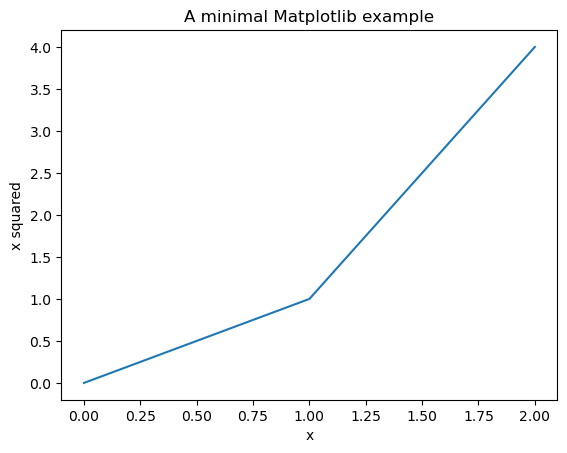

In [4]:
fig, ax = plt.subplots()
ax.plot([0, 1, 2], [0, 1, 4])
ax.set_xlabel('x')
ax.set_ylabel('x squared')
ax.set_title('A minimal Matplotlib example')
plt.show()

## 1. Where Are the Particles?

A scatter plot is appropriate because each particle is a separate observation with an $x$ and a $y$ coordinate. Connecting the particles with a line would incorrectly suggest an ordered path between them.

We set equal aspect ratio so that one unit along $x$ has the same visual length as one unit along $y$. Otherwise, a square simulation box may appear rectangular.

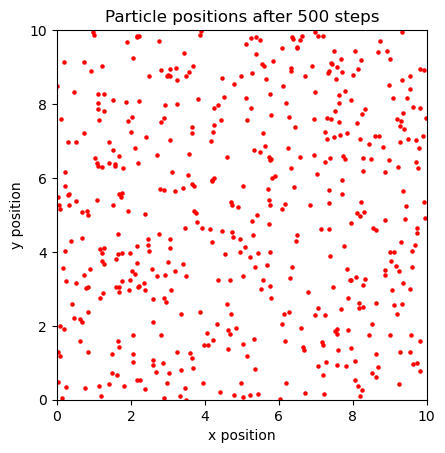

In [17]:
gas = ParticleSystem(
    N=500,
    box_length=10.0,
    temperature=1.5,
    mass=1.0,
    dt=0.01,
    seed=4,
)

gas.run(steps=500)

fig, ax = plt.subplots()
ax.scatter(
    gas.positions[:, 0],
    gas.positions[:, 1],
    s=5,
    color='red',
)
ax.set_xlim(0, gas.box_length)
ax.set_ylim(0, gas.box_length)
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax.set_title('Particle positions after 500 steps')
plt.show()

### Adding Velocity Vectors

A scatter plot shows position but not direction of motion. `ax.quiver` draws an arrow at each position. Its four main array arguments are $x$, $y$, $v_x$, and $v_y$.

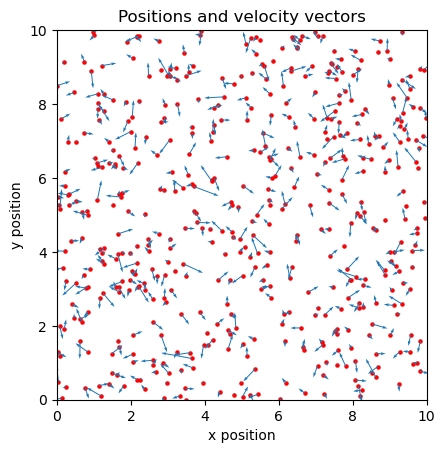

In [18]:
x = gas.positions[:, 0]
y = gas.positions[:, 1]
vx = gas.velocities[:, 0]
vy = gas.velocities[:, 1]

fig, ax = plt.subplots()
ax.scatter(x, y, s=5, color='red')
ax.quiver(x, y, vx, vy, color='tab:blue')
ax.set_xlim(0, gas.box_length)
ax.set_ylim(0, gas.box_length)
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax.set_title('Positions and velocity vectors')
plt.show()

### Interpretation

The arrows reveal direction and relative velocity, but this plot is not suitable for measuring the overall velocity distribution. For that question, individual particle identities are less important than how many particles fall within each speed range.

## 2. What Is the Distribution of Particle Speeds?

First calculate one speed per particle:

$$
v = \sqrt{v_x^2 + v_y^2}.
$$

A histogram groups these speeds into intervals. We use `density=True` so the total area of the histogram is approximately 1, allowing comparison with a probability-density curve.

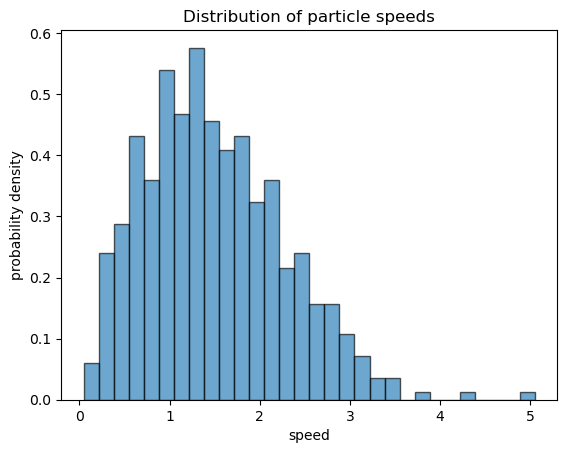

In [23]:
speeds = np.sqrt(np.sum(gas.velocities**2, axis=1))

fig, ax = plt.subplots()
ax.hist(
    speeds,
    bins=30,
    density=True,
    alpha=0.65,
    color='tab:blue',
    edgecolor='black',
)
ax.set_xlabel('speed')
ax.set_ylabel('probability density')
ax.set_title('Distribution of particle speeds')
plt.show()

### Comparing with the 2D Maxwell-Boltzmann Distribution

In two dimensions, when $k_B=1$, the theoretical speed density is

$$
f(v) = \frac{m v}{T}\exp\left(-\frac{m v^2}{2T}\right).
$$

A smooth theoretical curve should be drawn as a line. The simulated particles are sampled data, so they remain a histogram. Overlaying them allows direct comparison without implying that the histogram itself is exact.

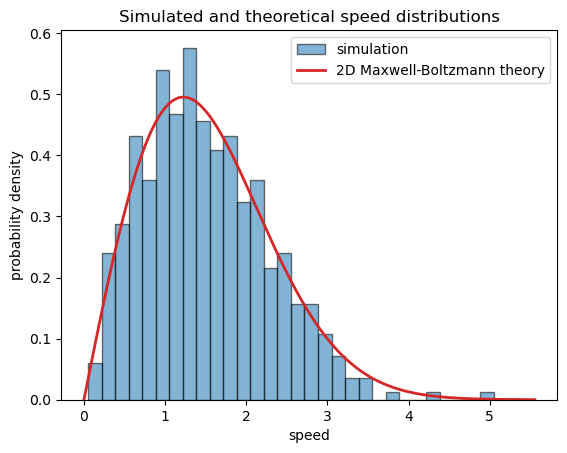

In [25]:
v_theory = np.linspace(0, speeds.max() * 1.1, 200)
mass = gas.mass
temperature = gas.temperature

speed_density = (
    mass * v_theory / temperature
    * np.exp(-mass * v_theory**2 / (2 * temperature))
)

fig, ax = plt.subplots()
ax.hist(
    speeds,
    bins=30,
    density=True,
    alpha=0.55,
    color='tab:blue',
    edgecolor='black',
    label='simulation',
)
ax.plot(
    v_theory,
    speed_density,
    color='tab:red',
    linewidth=2,
    label='2D Maxwell-Boltzmann theory',
)
ax.set_xlabel('speed')
ax.set_ylabel('probability density')
ax.set_title('Simulated and theoretical speed distributions')
ax.legend()
plt.show()

### Interpretation

The histogram will not follow the theoretical curve perfectly because it contains a finite number of particles. Changing the number or width of histogram bins also changes its appearance. The theoretical line is useful because it shows the expected continuous distribution independently of those display choices.

## A Helper for Repeated Pressure Measurements

A single simulation is one random realization. To estimate run-to-run variability, repeat the same experiment with different random seeds.

The function below creates and runs one gas, then returns its measured pressure. It lets the experimental sections focus on which parameter is changed and which quantity is plotted.

In [26]:
def measure_pressure(
    N,
    box_length,
    temperature,
    steps,
    seed,
    mass=1.0,
    dt=0.01,
):
    gas = ParticleSystem(
        N=N,
        box_length=box_length,
        temperature=temperature,
        mass=mass,
        dt=dt,
        seed=seed,
    )
    gas.run(steps)
    return gas.calculate_pressure()

## 3. How Does Pressure Depend on Temperature?

For a two-dimensional ideal gas in our dimensionless units,

$$
P A = N T,
$$

so at fixed particle number and box area,

$$
P = \frac{N}{A}T.
$$

We will run several independent simulations at each temperature. The plotted point is the mean pressure. The error bar is one standard deviation of the repeated results, representing run-to-run variability.

In [27]:
temperatures = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
repeats = 5

N = 200
box_length = 10.0
steps = 1200

mean_pressures = np.zeros(temperatures.size)
std_pressures = np.zeros(temperatures.size)

for i in range(temperatures.size):
    repeated_pressures = np.zeros(repeats)

    for repeat in range(repeats):
        repeated_pressures[repeat] = measure_pressure(
            N=N,
            box_length=box_length,
            temperature=temperatures[i],
            steps=steps,
            seed=100 * i + repeat,
        )

    mean_pressures[i] = np.mean(repeated_pressures)
    std_pressures[i] = np.std(repeated_pressures)

print(mean_pressures)
print(std_pressures)

[1.01509179 2.09941085 3.01655971 3.81116633 5.01020386 5.87537652]
[0.04058017 0.14632022 0.26789864 0.18771688 0.17115236 0.27762756]


### Plotting Data, Uncertainty, and Theory

`ax.errorbar` displays the simulated means and their variability. We use markers without connecting lines because these are measurements at selected temperatures. The theoretical prediction is continuous, so it is drawn as a line.

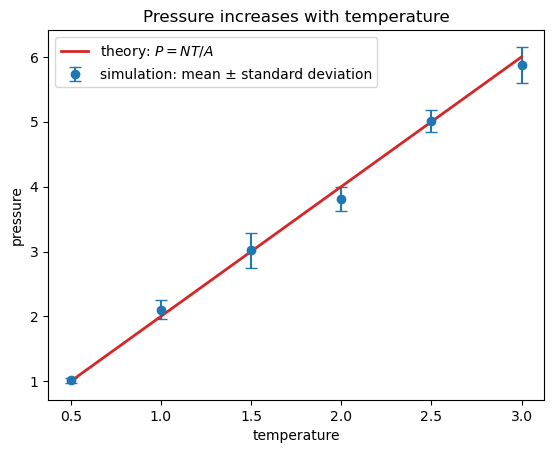

In [28]:
area = box_length**2
theoretical_pressures = N * temperatures / area

fig, ax = plt.subplots()
ax.errorbar(
    temperatures,
    mean_pressures,
    yerr=std_pressures,
    fmt='o',
    capsize=4,
    color='tab:blue',
    label='simulation: mean ± standard deviation',
)
ax.plot(
    temperatures,
    theoretical_pressures,
    color='tab:red',
    linewidth=2,
    label=r'theory: $P=NT/A$',
)
ax.set_xlabel('temperature')
ax.set_ylabel('pressure')
ax.set_title('Pressure increases with temperature')
ax.legend()
plt.show()

### Interpretation

Ask three separate questions when reading this graph:

1. Do the simulated means follow the predicted trend?
2. Are the differences from theory large compared with the error bars?
3. Does the size of the variability change with temperature?

Agreement does not mean every simulated point lies exactly on the theoretical line. A finite simulation produces fluctuations, and the pressure is measured over a limited time.

## 4. What Changes in the Large-$N$ Limit?

Macroscopic gases contain enormous numbers of particles and appear stable. Our simulations contain far fewer particles, so repeated runs can give noticeably different pressure measurements.

To isolate the effect of particle number, keep the particle density constant. If $N$ increases, increase the box area proportionally:

$$
A = \frac{N}{\rho}.
$$

At fixed density and temperature, the theoretical pressure remains constant. We can then examine the **relative fluctuation** between repeated runs:

$$
\text{relative fluctuation} = \frac{\text{standard deviation of } P}
{\text{mean of } P}.
$$

In [29]:
particle_counts = np.array([50, 100, 200, 400, 800])
repeats = 6

density = 2.0
temperature = 1.5
steps = 1200

mean_pressure_by_N = np.zeros(particle_counts.size)
relative_fluctuation = np.zeros(particle_counts.size)

for i in range(particle_counts.size):
    N = int(particle_counts[i])
    area = N / density
    box_length = np.sqrt(area)
    repeated_pressures = np.zeros(repeats)

    for repeat in range(repeats):
        repeated_pressures[repeat] = measure_pressure(
            N=N,
            box_length=box_length,
            temperature=temperature,
            steps=steps,
            seed=1000 + 100 * i + repeat,
        )

    mean_pressure_by_N[i] = np.mean(repeated_pressures)
    relative_fluctuation[i] = (
        np.std(repeated_pressures) / mean_pressure_by_N[i]
    )

print(mean_pressure_by_N)
print(relative_fluctuation)

[2.99511041 2.84841519 3.04095244 2.97763407 3.0061253 ]
[0.17084903 0.09737028 0.08033743 0.02243878 0.0240143 ]


### Plotting Relative Fluctuation

The particle count spans more than one order of magnitude, so a logarithmic $x$ axis makes the spacing easier to read. `ax.set_xscale('log')` changes only the display scale; the underlying particle counts are unchanged.

For independent contributions, relative fluctuations often decrease approximately as $1/\sqrt{N}$. We add a guide curve with that shape, scaled to the first simulated point. It is a scaling comparison, not an additional fitted law.

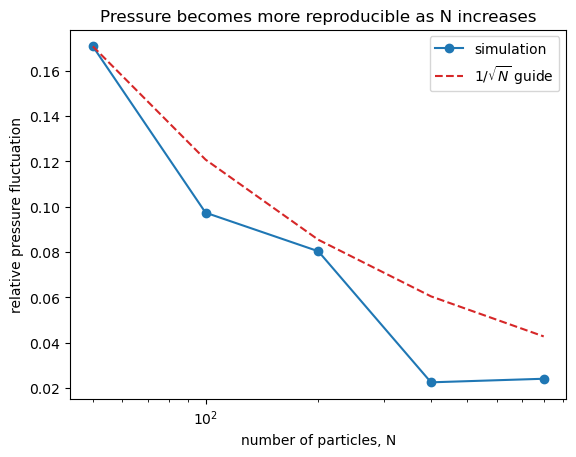

In [30]:
fluctuation_guide = (
    relative_fluctuation[0]
    * np.sqrt(particle_counts[0] / particle_counts)
)

fig, ax = plt.subplots()
ax.plot(
    particle_counts,
    relative_fluctuation,
    'o-',
    color='tab:blue',
    label='simulation',
)
ax.plot(
    particle_counts,
    fluctuation_guide,
    '--',
    color='tab:red',
    label=r'$1/\sqrt{N}$ guide',
)
ax.set_xscale('log')
ax.set_xlabel('number of particles, N')
ax.set_ylabel('relative pressure fluctuation')
ax.set_title('Pressure becomes more reproducible as N increases')
ax.legend()
plt.show()

### Interpretation

The mean pressure should remain approximately constant because density and temperature are fixed. The relative fluctuation should generally decrease as the number of particles grows. Individual points need not decrease perfectly because each estimate is itself based on a finite number of repeated simulations.

This is one computational view of the large-$N$ limit: microscopic motion remains random, but relative fluctuations become less important for macroscopic observables.